In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

In [2]:
PROJECT_ROOT = Path.cwd()

# Если ноутбук открыт из папки notebooks/, поднимаемся в корень проекта
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
OUTPUTS = PROJECT_ROOT / "outputs"
ANNOTATIONS_DIR = OUTPUTS / "annotations"
FIGURES_DIR = OUTPUTS / "figures"

for folder in [DATA_RAW, ANNOTATIONS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)
print("Outputs folder:", OUTPUTS)

Project root: /Users/user/Documents/emg-lr-segmentation
Raw data folder: /Users/user/Documents/emg-lr-segmentation/data/raw
Outputs folder: /Users/user/Documents/emg-lr-segmentation/outputs


In [4]:
fif_path = DATA_RAW / "3_3_rhythm_late_responses_raw.fif"

assert fif_path.exists(), f"Файл не найден: {fif_path}"

raw = mne.io.read_raw_fif(fif_path, preload=True)
raw_original = raw.copy()
raw_work = raw.copy()

print(raw)
print(raw.ch_names)
print("sfreq:", raw.info["sfreq"])

Opening raw data file /Users/user/Documents/emg-lr-segmentation/data/raw/3_3_rhythm_late_responses_raw.fif...
Isotrak not found
    Range : 0 ... 164899 =      0.000 ...    41.225 secs
Ready.
Reading 0 ... 164899  =      0.000 ...    41.225 secs...
<Raw | 3_3_rhythm_late_responses_raw.fif, 7 x 164900 (41.2 s), ~8.8 MiB, data loaded>
['EMG1', 'EMG2', 'EMG3', 'EMG4', 'EMG5', 'EMG6', 'EMG7']
sfreq: 4000.0


In [12]:
raw.plot(duration=10, n_channels=16)

Channels marked as bad:
none


In [4]:
# Сохраняем разметку в файл прямо рядом с вашим кодом
raw.annotations.save("lr_annotations_31_05_2026.csv", overwrite=True)
print(raw.annotations)

Overwriting existing file.
<Annotations | 1322 segments: ER (23), LR (30), Stimulus (22), ...>


In [ ]:
events, event_id = mne.events_from_annotations(raw)
print("Все найденные метки:", event_id)

tmin = 0.0
tmax = 0.6 

epochs = mne.Epochs(
    raw, 
    events=events, 
    event_id=event_id['Stimulus'], # Режем ТОЛЬКО по этой метке
    tmin=tmin, 
    tmax=tmax, 
    preload=True,
    baseline=None # Отключаем коррекцию, если просто смотрим сигнал
)

Used Annotations descriptions: [np.str_('Stimulus')]
Все найденные метки: {np.str_('Stimulus'): 1}
Not setting metadata
9 matching events found


No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 9 events and 8001 original time points ...
0 bad epochs dropped


In [9]:
# Авторазметка всех стимулов по каналу Art без ручного первого Stimulus

stim_ch = "EMG7"
stim_label = "Stimulus_Auto"

assert stim_ch in raw.ch_names, f"Канал {stim_ch} не найден. Доступные каналы: {raw.ch_names}"

sfreq = raw.info["sfreq"]

# 1. Берем Art
art_data, art_times = raw.copy().pick([stim_ch]).get_data(return_times=True)
art = art_data[0]

# 2. Центрируем и берём модуль: стимул на Art может быть положительным или отрицательным
art_centered = art - np.median(art)
art_abs = np.abs(art_centered)

# 3. Robust threshold через MAD
art_abs_median = np.median(art_abs)
art_abs_mad = 1.4826 * np.median(np.abs(art_abs - art_abs_median))

peak_threshold = art_abs_median + 8.0 * art_abs_mad

# Минимальная дистанция между стимулами.
# Для ритма около 33 ms ставим 25 ms, чтобы не поймать один стимул дважды.
stim_min_distance_ms = 25.0
stim_min_distance_samples = int(round(stim_min_distance_ms / 1000 * sfreq))

# 4. Ищем кандидаты стимулов
stim_samples, props = find_peaks(
    art_abs,
    height=peak_threshold,
    distance=stim_min_distance_samples,
)

if len(stim_samples) == 0:
    raise RuntimeError(
        "Не найдено ни одного стимула на Art. "
        "Проверь stim_ch, peak_threshold или визуально канал Art."
    )

stim_onsets = stim_samples / sfreq

print(f"Найдено Stimulus_Auto: {len(stim_samples)}")
print(f"Threshold Art abs: {peak_threshold:.3e}")

# 5. Проверяем ISI
isi_ms = np.diff(stim_samples) / sfreq * 1000

print("ISI median, ms:", np.median(isi_ms))
print("ISI mean, ms:", np.mean(isi_ms))
print("ISI min/max, ms:", np.min(isi_ms), np.max(isi_ms))
print("ISI 1/99 percentiles, ms:", np.percentile(isi_ms, [1, 99]))

# 6. Удаляем только старые Stimulus_Auto, ручные ER/LR/Stimulus не трогаем
old_ann = raw.annotations

keep_mask = np.array(old_ann.description) != stim_label

clean_annotations = mne.Annotations(
    onset=np.array(old_ann.onset)[keep_mask],
    duration=np.array(old_ann.duration)[keep_mask],
    description=np.array(old_ann.description)[keep_mask],
    orig_time=old_ann.orig_time,
)

# 7. Добавляем новые автостимулы
auto_stim_annotations = mne.Annotations(
    onset=stim_onsets,
    duration=np.zeros(len(stim_onsets)),
    description=[stim_label] * len(stim_onsets),
    orig_time=old_ann.orig_time,
)

raw.set_annotations(clean_annotations + auto_stim_annotations)

print(raw.annotations)
print("Stimulus_Auto count:", np.sum(raw.annotations.description == stim_label))

Найдено Stimulus_Auto: 1247
Threshold Art abs: 8.797e-07
ISI median, ms: 33.0
ISI mean, ms: 33.05477528089887
ISI min/max, ms: 27.25 38.75
ISI 1/99 percentiles, ms: [33.   33.25]
<Annotations | 1247 segments: Stimulus_Auto (1247)>
Stimulus_Auto count: 1247


In [92]:

# 1. Конвертируем текстовые аннотации Stimulus_Auto в события MNE (Events)
events, event_id = mne.events_from_annotations(raw, regexp='Stimulus_Auto')

# 2. Задаем временное окно эпохи (от стимула до стимула)
tmin = 0.0     # Начало эпохи (0 мс — сам момент стимула)
tmax = 0.033    # Конец эпохи (330 мс — аккурат перед следующим стимулом)

# 3. Нарезаем эпохи
# baseline=None означает, что мы пока не вычитаем среднее пре-стимульное значение
# preload=True загружает данные в оперативную память для быстрой работы
epochs = mne.Epochs(
    raw, 
    events=events, 
    event_id=event_id, 
    tmin=tmin, 
    tmax=tmax, 
    baseline=None, 
    preload=True
)

print(f"🎯 Успешно нарезано эпох: {len(epochs)}")
print(f"📐 Форма массива данных эпох (epochs, channels, times): {epochs.get_data().shape}")

Used Annotations descriptions: [np.str_('Stimulus_Auto')]
Not setting metadata
1247 matching events found
No baseline correction applied


0 projection items activated
Using data from preloaded Raw for 1247 events and 133 original time points ...
1 bad epochs dropped
🎯 Успешно нарезано эпох: 1246
📐 Форма массива данных эпох (epochs, channels, times): (1246, 7, 133)


Used Annotations descriptions: ['Stimulus_Auto']
n stimuli: 1247
ISI median, ms: 33.0
ISI min/max, ms: 27.25 38.75


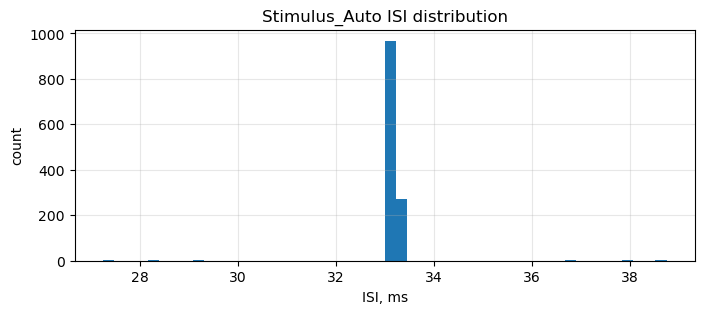

In [10]:
events_auto, event_id_auto = mne.events_from_annotations(raw, regexp="Stimulus_Auto")

stim_id_auto = event_id_auto["Stimulus_Auto"]
stim_samples_auto = events_auto[events_auto[:, 2] == stim_id_auto][:, 0]

isi_ms = np.diff(stim_samples_auto) / raw.info["sfreq"] * 1000

print("n stimuli:", len(stim_samples_auto))
print("ISI median, ms:", np.median(isi_ms))
print("ISI min/max, ms:", np.min(isi_ms), np.max(isi_ms))

plt.figure(figsize=(8, 3))
plt.hist(isi_ms, bins=50)
plt.xlabel("ISI, ms")
plt.ylabel("count")
plt.title("Stimulus_Auto ISI distribution")
plt.grid(True, alpha=0.3)
plt.show()

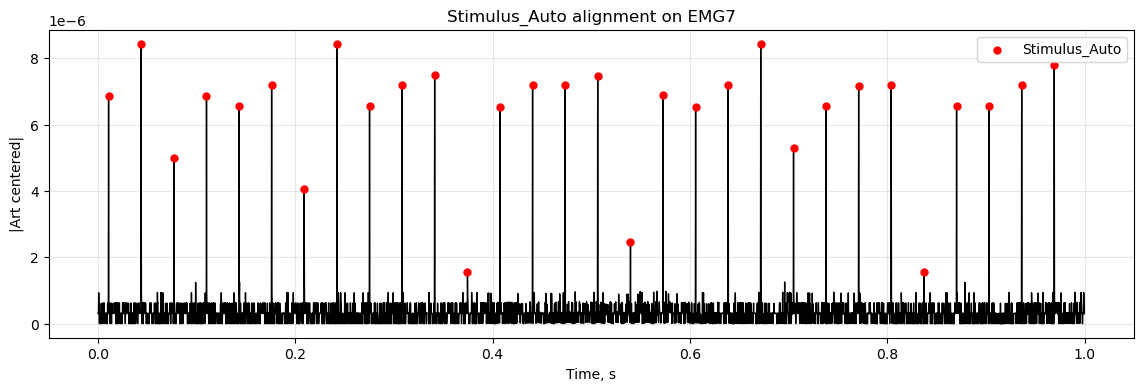

In [11]:
# Визуальная проверка Stimulus_Auto на коротком фрагменте Art

start_s = 0.0
duration_s = 1.0

start_sample = int(start_s * sfreq)
stop_sample = int((start_s + duration_s) * sfreq)

t_plot = art_times[start_sample:stop_sample]
art_plot = art_abs[start_sample:stop_sample]

stim_in_window = stim_samples_auto[
    (stim_samples_auto >= start_sample) & (stim_samples_auto < stop_sample)
]

plt.figure(figsize=(14, 4))
plt.plot(t_plot, art_plot, color="black", lw=1)

plt.scatter(
    stim_in_window / sfreq,
    art_abs[stim_in_window],
    color="red",
    s=25,
    zorder=3,
    label="Stimulus_Auto",
)

plt.xlabel("Time, s")
plt.ylabel("|Art centered|")
plt.title(f"Stimulus_Auto alignment on {stim_ch}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [56]:
epochs = mne.Epochs(
    raw, 
    events=filtered_stim_events, 
    event_id=stim_id,
    tmin=0.0, 
    tmax=epoch_duration,          
    picks=['GM R'],  # Оставляем только нужный канал            
    baseline=None,
    preload=True
)

# Защита от ошибок np.int64 для словаря цветов в MNE
labels_to_show = {k: v for k, v in event_id.items() if k in ['ER', 'LR']}
custom_colors = {
    np.int64(er_id): 'green',  
    np.int64(lr_id): 'blue',   
    np.int64(stim_id): 'lightgray'
}

print("🚀 Запуск интерактивного окна MNE...")
print("📌 ВАЖНО: Закройте открывшееся окно графиков, чтобы разблокировать блокнот для следующей ячейки!")

# Открываем встроенный браузер MNE
epochs.plot(
    n_epochs=10,               
    n_channels=1,              
    scalings='auto',      
    events=events,             
    event_id=labels_to_show, 
    event_color=custom_colors,
    picks='all',
    block=True  # Ждем, пока вы закроете окно, прежде чем выполнять код дальше
)

Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 10 events and 133 original time points ...
0 bad epochs dropped
🚀 Запуск интерактивного окна MNE...
📌 ВАЖНО: Закройте открывшееся окно графиков, чтобы разблокировать блокнот для следующей ячейки!


qt.core.qobject.connect: QObject::connect(QStyleHints, QStyleHints): unique connections require a pointer to member function of a QObject subclass


Using pyopengl with version 3.1.9
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


<mne_qt_browser._pg_figure.MNEQtBrowser(0x0) at 0x199be5040>

In [ ]:
# 1. Находим индексы эпох, где есть И волна ER, И волна LR
valid_indices = []
for i, meta in enumerate(valid_meta):
    # Проверяем, что списки ER и LR внутри этой эпохи не пусты
    if meta['ER'] and meta['LR']:
        valid_indices.append(i)

print(f"🔍 Всего в записи найдено {len(valid_indices)} эпох, содержащих одновременно ER и LR.")

# 2. Берем первые 10 эпох (или сколько есть, если вдруг меньше 10)
indices_to_plot = valid_indices[:10]

if len(indices_to_plot) == 0:
    print("Не найдено ни одной эпохи, где одновременно размечены и ER, и LR. Проверьте названия меток.")
else:
    # 3. Строим сетку графиков 2x5 или сколько необходимо
    n_plots = len(indices_to_plot)
    ncols = 5
    nrows = int(np.ceil(n_plots / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows), sharex=True, sharey=True)
    axes = axes.flatten() if n_plots > 1 else [axes]
    
    # Получаем данные отфильтрованных эпох (для красивого гладкого отображения)
    epochs_data = epochs_filtered.get_data(picks=['GM R'])[:, 0, :]
    times_ms = epochs_filtered.times * 1000
    
    for plot_idx, epoch_idx in enumerate(indices_to_plot):
        ax = axes[plot_idx]
        signal = epochs_data[epoch_idx] * 1e6  # Переводим в мкВ
        
        ax.plot(times_ms, signal, color='black', lw=1.2, label='Signal')
        
        # Подсвечиваем зоны ER (зеленым) и LR (синим) прямо из вашей ручной разметки
        meta = valid_meta[epoch_idx]
        stim_onset = meta['onset']
        
        # Рисуем ER
        for er in meta['ER']:
            start_ms = (er['onset'] - stim_onset) * 1000
            end_ms = start_ms + (er['duration'] * 1000)
            ax.axvspan(start_ms, end_ms, color='green', alpha=0.2, label='ER' if plot_idx==0 else "")
            
        # Рисуем LR
        for lr in meta['LR']:
            start_ms = (lr['onset'] - stim_onset) * 1000
            end_ms = start_ms + (lr['duration'] * 1000)
            ax.axvspan(start_ms, end_ms, color='blue', alpha=0.2, label='LR' if plot_idx==0 else "")
            
        ax.grid(True, linestyle=':', alpha=0.5)
        
    # Удаляем пустые окошки, если эпох оказалось меньше, чем ячеек в сетке
    for j in range(plot_idx + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Добавляем общую легенду и подписи
    axes[0].legend(fontsize=8, loc='upper right')
    fig.text(0.5, 0.01, 'Time from Stimulus (ms)', ha='center', fontsize=11)
    fig.text(0.01, 0.5, r'Amplitude ($\mu$V)', va='center', rotation='vertical', fontsize=11)
    plt.suptitle("GM R Channel", fontsize=12, weight='bold', y=0.98)
    plt.tight_layout()
    plt.show()